In [1]:
!pip install sympy pandas numpy matplotlib control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 14.2 MB/s eta 0:00:00


In [ ]:
import sys
!{sys.executable} -m pip install sympy pandas numpy matplotlib control

In [ ]:
import sympy as sym
from sympy import MatrixSymbol, Matrix, Identity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import control

np.set_printoptions(precision=6, suppress=True)
sym.init_printing()
print("Todo importado correctamente ✅")

Todo importado correctamente ✅


In [ ]:
%cd "C:/Users/monsa/Downloads"

C:\Users\monsa\Downloads


# IDENTIFICACION DE SISTEMAS - Laboratorio 4

Profesor: Jairo Alberto Cuéllar Guarnizo  
Programa: Ingeniería en Automatización y Control

# Elaborado por:

* Mateo, Monsalve
* Thomas, Alarcón

# 2. Polinomio Autoregresivo ARX

Utilice los datos capturados para la entrega anterior del proyecto y aplique los métodos discutidos en los noteboks 8_1 y 8_2.

Plantee 2 hipótesis diferentes usando el modelo ARX y para cada uno proceda de la siguiente manera:

2.1. Reconstruya la ecuación en diferencia usando la estructura del modelo entrada salida:

$$y_e[k] = a_1y[k-1] + ...+ a_{n_a}y[k-{n_a}] + b_0u[k]+ b_1u[k-1]+...+b_{n_b}u[k-{n_b}] + C_1$$

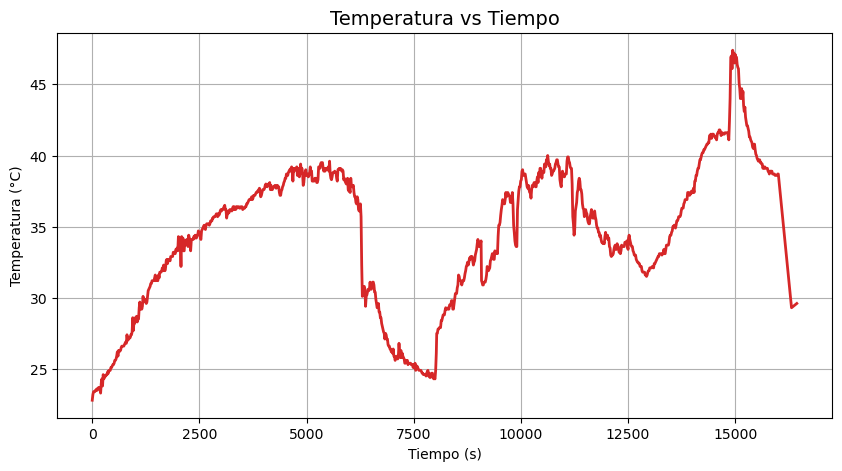

In [ ]:
# Carga datos
df = pd.read_csv('TCLAB.csv')

# Crea datetime combinando fecha y hora (forzando formato día/mes/año)
df['datetime_combined'] = pd.to_datetime(
    df['Fecha'] + ' ' + df['hora'],
    format='%d-%m-%Y %H:%M:%S'
)

# Ordena por fecha-hora
df = df.sort_values('datetime_combined').reset_index(drop=True)

# Crea lista para guardar cada bloque de mediciones por día
bloques = []
offset = 0  # tiempo acumulado total

for fecha, grupo in df.groupby('Fecha'):
    grupo = grupo.copy()
    grupo['time_s'] = (grupo['datetime_combined'] - grupo['datetime_combined'].iloc[0]).dt.total_seconds()
    grupo['time_s'] += offset  # continua desde el bloque anterior
    offset = grupo['time_s'].iloc[-1] + 10
    bloques.append(grupo)

# Une todos los bloques
df_proc = pd.concat(bloques, ignore_index=True)

#
plt.figure(figsize=(10,5))
plt.plot(df_proc['time_s'], df_proc['temperatura'], color='tab:red', lw=2)
plt.title('Temperatura vs Tiempo', fontsize=14)
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

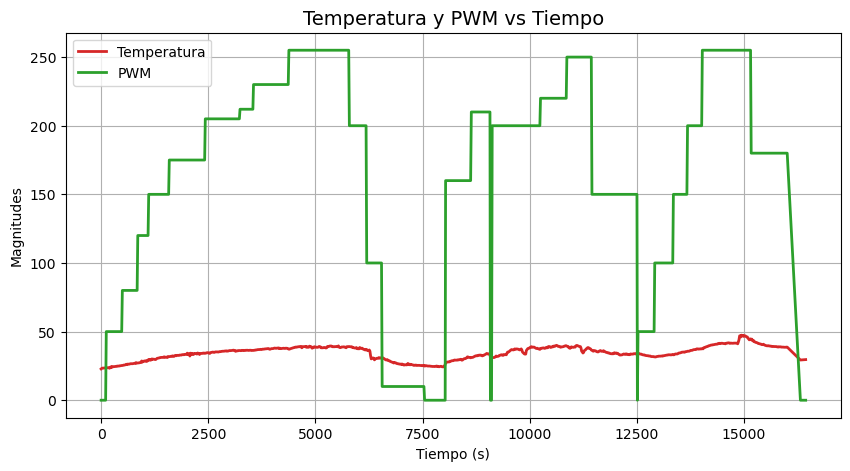

In [ ]:
# Carga datos
df = pd.read_csv('TCLAB.csv')

# Crea datetime combinando fecha y hora (forzando formato día/mes/año)
df['datetime_combined'] = pd.to_datetime(
    df['Fecha'] + ' ' + df['hora'],
    format='%d-%m-%Y %H:%M:%S'
)

# Ordena por fecha-hora
df = df.sort_values('datetime_combined').reset_index(drop=True)

# Crea lista para guardar cada bloque de mediciones por día
bloques = []
offset = 0  # tiempo acumulado total

for fecha, grupo in df.groupby('Fecha'):
    grupo = grupo.copy()
    grupo['time_s'] = (grupo['datetime_combined'] - grupo['datetime_combined'].iloc[0]).dt.total_seconds()
    grupo['time_s'] += offset  # continua desde el bloque anterior
    offset = grupo['time_s'].iloc[-1] + 10
    bloques.append(grupo)

# Une todos los bloques
df_proc = pd.concat(bloques, ignore_index=True)

# Gráfica temperatura + PWM
plt.figure(figsize=(10,5))

# Salida: temperatura
plt.plot(df_proc['time_s'], df_proc['temperatura'], color='tab:red', lw=2, label='Temperatura')

# Entrada: PWM
plt.plot(df_proc['time_s'], df_proc['PWM'], color='tab:green', lw=2, label='PWM')

plt.title('Temperatura y PWM vs Tiempo', fontsize=14)
plt.xlabel('Tiempo (s)')
plt.ylabel('Magnitudes')
plt.grid(True)
plt.legend()
plt.show()


# Hipótesis 1


Theta estimado:
 [ 0.968206 -0.012644  0.006477 -0.004586  0.000772  1.05532 ]

ONE-STEP :  ECM=0.3375   R²=0.9787
FREE-RUN : ECM=11.9118   R²=0.2480


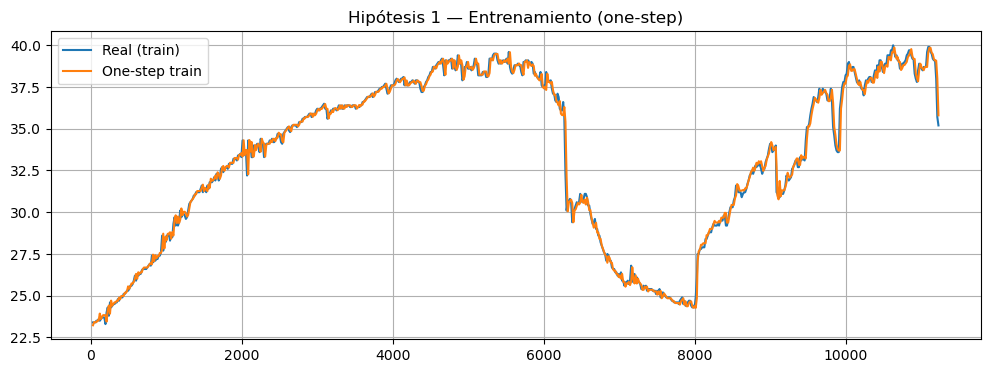

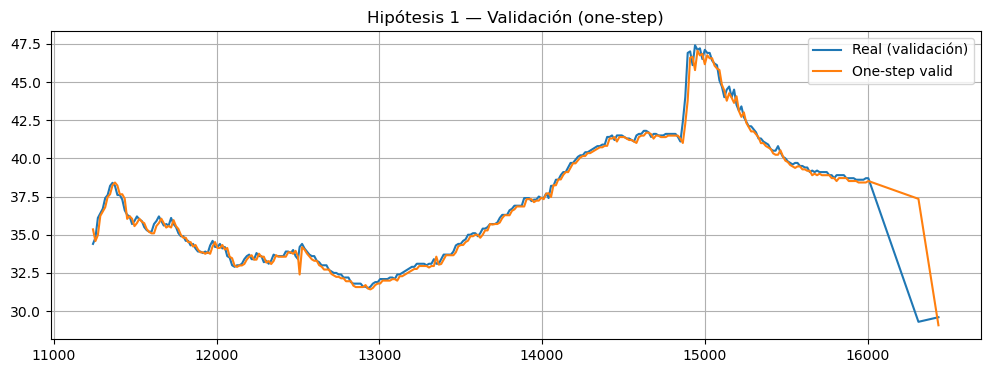

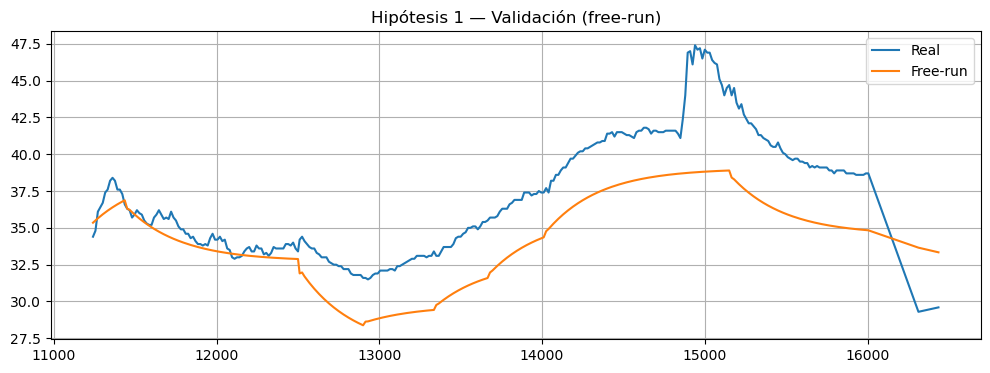

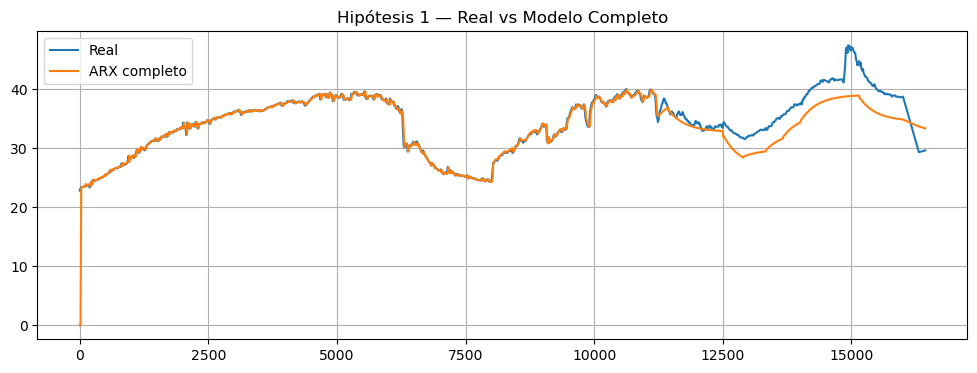

In [ ]:
#Estimación

n_a = 2
n_b = 2
include_C1 = True
alpha = 0.0
train_frac = 0.7

# Señales
y = df_proc['temperatura'].to_numpy()
u = df_proc['PWM'].to_numpy()
N = len(y)
start_k = max(n_a, 1)

# Split temporal
split = int(N * train_frac)

# Construcción Phi entrenamiento
rows_tr, y_tr = [], []
for k in range(start_k, split):
    row = []
    for i in range(1, n_a+1):
        row.append(y[k - i])
    for j in range(0, n_b+1):
        row.append(u[k - j])
    if include_C1:
        row.append(1.0)
    rows_tr.append(row)
    y_tr.append(y[k])

Phi_tr = np.array(rows_tr)
y_tr = np.array(y_tr)

# Estimación theta
P = Phi_tr.shape[1]
A = Phi_tr.T @ Phi_tr
theta = np.linalg.solve(A + alpha * np.eye(P), Phi_tr.T @ y_tr)

print("\nTheta estimado:\n", theta)

# ONE-STEP VALIDATION
rows_val, y_val = [], []
for k in range(max(start_k, split), N):
    row = []
    for i in range(1, n_a+1):
        row.append(y[k - i])
    for j in range(0, n_b+1):
        row.append(u[k - j])
    if include_C1:
        row.append(1.0)
    rows_val.append(row)
    y_val.append(y[k])

Phi_val = np.array(rows_val)
y_val = np.array(y_val)
y_pred_one = Phi_val @ theta

# FREE-RUN
y_sim = np.zeros(N - split)
buf = list(y[split - n_a: split])

for k_idx in range(N - split):

    suma_a = 0
    for i in range(1, n_a+1):
        suma_a += theta[i-1] * buf[-i]

    suma_b = 0
    for j in range(0, n_b+1):
        if split + k_idx - j >= 0:
            suma_b += theta[n_a + j] * u[split + k_idx - j]

    C1 = theta[-1] if include_C1 else 0.0

    y_new = suma_a + suma_b + C1
    y_sim[k_idx] = y_new
    buf.append(y_new)

#  MÉTRICAS
def mse(a,b): return np.mean((a-b)**2)
def r2(a,b): return 1 - np.sum((a-b)**2)/np.sum((a - np.mean(a))**2)

print(f"\nONE-STEP :  ECM={mse_one:.4f}   R²={r2_one:.4f}")
print(f"FREE-RUN : ECM={mse_free:.4f}   R²={r2_free:.4f}")

mse_one = mse(y_val, y_pred_one)
r2_one  = r2(y_val, y_pred_one)
mse_free = mse(y[split:], y_sim)
r2_free = r2(y[split:], y_sim)

# Preparar señal completa para gráfica final
y_e_full = np.zeros_like(y)
y_e_full[start_k:split] = Phi_tr @ theta
y_e_full[split:] = y_sim

# GRÁFICAS

t = df_proc["time_s"].to_numpy()

plt.figure(figsize=(12,4))
plt.plot(t[start_k:split], y[start_k:split], label="Real (train)")
plt.plot(t[start_k:split], Phi_tr @ theta, label="One-step train")
plt.title("Hipótesis 1 — Entrenamiento (one-step)")
plt.grid(); plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t[split:], y_val, label="Real (validación)")
plt.plot(t[split:], y_pred_one, label="One-step valid")
plt.title("Hipótesis 1 — Validación (one-step)")
plt.grid(); plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t[split:], y[split:], label="Real")
plt.plot(t[split:], y_sim, label="Free-run")
plt.title("Hipótesis 1 — Validación (free-run)")
plt.grid(); plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t, y, label="Real")
plt.plot(t, y_e_full, label="ARX completo")
plt.title("Hipótesis 1 — Real vs Modelo Completo")
plt.grid(); plt.legend()
plt.show()



2.2. Obtenga una función de transferencia estimada usando los coeficientes hallados en el punto anterior:

$$G(z) = \frac{b_0+b_1z^{-1}+b_2z^{-2}+...+b_{n_b}z^{-{n_b}}}{1+a_1z^{-1}+...+a_{n_a}z^{-{n_a}}}$$

In [ ]:
# Función de transferencia

a_coeffs = theta[:n_a]
b_coeffs = theta[n_a:n_a+n_b+1]

den = [1] + list(a_coeffs)
num = list(b_coeffs)

t = df_proc["time_s"].to_numpy()
dt = np.mean(np.diff(t))

Gz = control.tf(num, den, dt)

print("\nG(z) estimada\n")
print(Gz)


G(z) estimada

<TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 15.389513108614231

  0.006477 z^2 - 0.004586 z + 0.000772
  ------------------------------------
        z^2 + 0.9682 z - 0.01264


In [ ]:
#  ECM y R2

a = theta[0:n_a]
b = theta[n_a:n_a+n_b+1]

y = df_proc["temperatura"].values
u = df_proc["PWM"].values

y_e = np.zeros_like(y)
k_min = max(n_a, n_b)

for k in range(k_min, len(y)):
    suma_a = sum(a[i-1] * y[k-i] for i in range(1, n_a+1))
    suma_b = sum(b[j]   * u[k-j] for j in range(0, n_b+1))
    y_e[k] = suma_a + suma_b

SS_res = np.sum((y[k_min:] - y_e[k_min:])**2)
SS_tot = np.sum((y[k_min:] - np.mean(y[k_min:]))**2)

R2 = 1 - SS_res/SS_tot
ECM = np.mean((y[k_min:] - y_e[k_min:])**2)

print(f"\nECM: {ECM:.4f}")
print(f"R²: {R2:.4f}")


ECM: 1.3862
R²: 0.9444


# Hipotesis #2


Theta estimado (Hipótesis 2):
 [ 0.967744  0.008322 -0.019979  0.006468 -0.004584  0.00075   1.042123]
a coeffs: [ 0.967744  0.008322 -0.019979]
b coeffs: [ 0.006468 -0.004584  0.00075 ]
C1: 1.0421232005398884

Métricas (Hipótesis 2):
Train one-step:   ECM=1.371807e-01, R2=0.994365
Val one-step:     ECM=3.367650e-01, R2=0.978741
Val free-run:     ECM=1.196343e+01, R2=0.244783

Gd discreta:
<TransferFunction>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 15.389513108614231

    0.006468 z^2 - 0.004584 z + 0.00075
  ---------------------------------------
  z^3 + 0.9677 z^2 + 0.008322 z - 0.01998


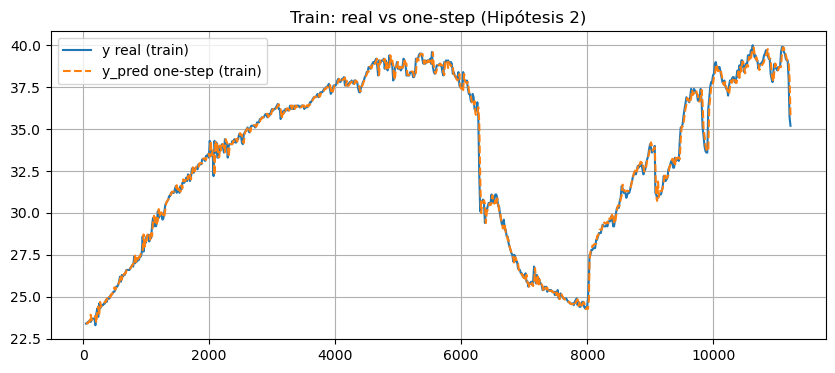

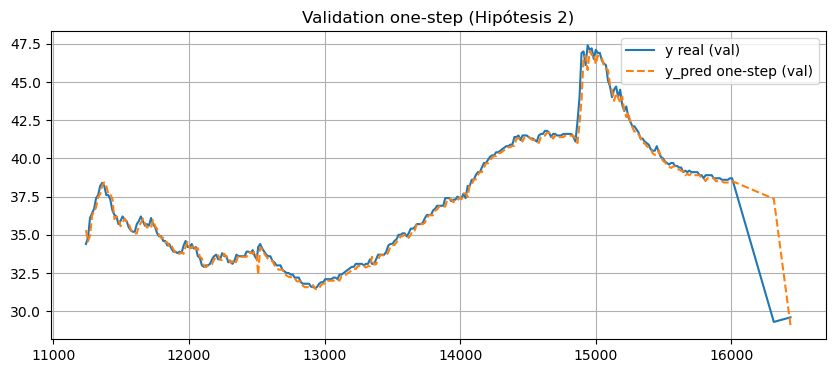

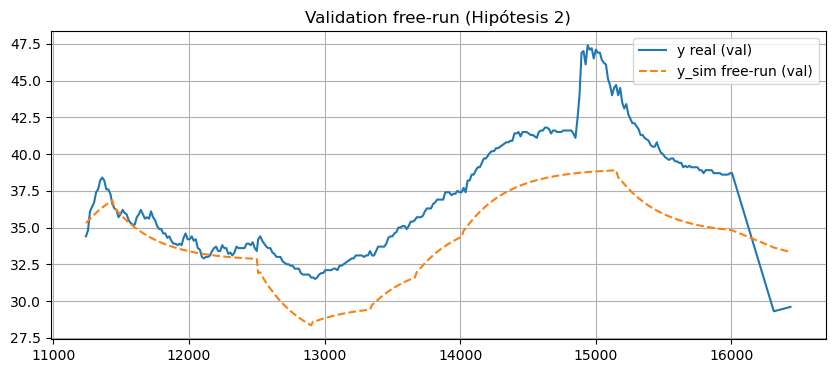

In [ ]:
# Hipótesis 2: ARX con retardo (nk)


# Configuración del modelo
n_a = 3
n_b = 2
include_C1 = True
alpha = 0.0
train_frac = 0.7

# Señales y tiempo
t = df_proc['time_s'].to_numpy()
y = df_proc['temperatura'].to_numpy().astype(float)
u = df_proc['PWM'].to_numpy().astype(float)
dt = np.mean(np.diff(t))
N = len(y)

# Sstimación de nk (simple: detección de pasos + fallback xcorr)
def estimate_nk(u, y, t, dt, step_threshold=20.0, fraction=0.10):
    # deteccion de pasos
    diff_u = np.diff(u)
    step_idx = np.where(np.abs(diff_u) >= step_threshold)[0] + 1
    delays = []
    for idx in step_idx:
        baseline = np.mean(y[max(0, idx-20):idx])
        # búsqueda hasta 200 s
        search_zone = y[idx: min(len(y), idx + int(200/dt))]
        if search_zone.size==0:
            continue
        # buscar primer cambio de 0.05 C respecto baseline
        up = np.where(search_zone >= baseline + 0.05)[0]
        down = np.where(search_zone <= baseline - 0.05)[0]
        if up.size>0:
            j = idx + up[0]; delays.append(t[j]-t[idx])
        elif down.size>0:
            j = idx + down[0]; delays.append(t[j]-t[idx])
    # correlación cruzada fallback
    u0 = (u - np.mean(u)) / (np.std(u) + 1e-12)
    y0 = (y - np.mean(y)) / (np.std(y) + 1e-12)
    xc = np.correlate(u0 - np.mean(u0), y0 - np.mean(y0), mode='full')
    lags = np.arange(-len(u0)+1, len(u0))
    lag_at_max = lags[np.argmax(xc)]
    delay_xcorr = lag_at_max * dt
    if len(delays)>0:
        nk = int(round(np.median(delays)/dt))
    else:
        nk = max(1, int(round(abs(delay_xcorr)/dt)))
    return nk, np.array(delays), delay_xcorr, step_idx

nk, delays_sec, delay_xcorr_sec, step_idx = estimate_nk(u,y,t,dt)

# Preparar split
start_k = max(n_a, nk + n_b)
split = int(N * train_frac)
if split <= start_k:
    raise ValueError("split demasiado pequeño. Reduce train_frac o n_a/n_b/nk.")

# Construir Phi y y_trim (train) teniendo en cuenta nk
rows_tr = []; y_tr = []
for k in range(start_k, split):
    row = []
    # a terms: y[k-1]..y[k-n_a]
    for i in range(1, n_a+1):
        row.append(y[k - i])
    # b terms: b0*u[k-nk], b1*u[k-1-nk], ...
    for j in range(0, n_b+1):
        idx = k - j - nk
        row.append(u[idx] if idx >= 0 else 0.0)
    if include_C1:
        row.append(1.0)
    rows_tr.append(row); y_tr.append(y[k])
Phi_tr = np.array(rows_tr); y_tr = np.array(y_tr)

# Estimación theta
P = Phi_tr.shape[1]
theta = np.linalg.solve(Phi_tr.T @ Phi_tr + alpha*np.eye(P), Phi_tr.T @ y_tr)
a_coeffs = theta[0:n_a]
b_coeffs = theta[n_a:n_a + (n_b+1)]
C1_val = theta[-1] if include_C1 else 0.0

print("\nTheta estimado (Hipótesis 2):\n", theta)
print("a coeffs:", a_coeffs)
print("b coeffs:", b_coeffs)
if include_C1: print("C1:", C1_val)

# Predicción one-step en train
y_pred_train = (Phi_tr @ theta)

# Validación one-step
rows_val = []; y_val = []
for k in range(max(start_k, split), N):
    row=[]
    for i in range(1, n_a+1):
        row.append(y[k - i])
    for j in range(0, n_b+1):
        idx = k - j - nk
        row.append(u[idx] if idx >= 0 else 0.0)
    if include_C1:
        row.append(1.0)
    rows_val.append(row); y_val.append(y[k])
Phi_val = np.array(rows_val); y_val = np.array(y_val)
y_pred_one_val = Phi_val @ theta

# Validación free-run
y_sim = np.zeros(N - split)
# init buffer con últimos n_a reales del entrenamiento
buf = list(y[split - n_a: split])
for k_idx in range(N - split):
    suma_a = sum(a_coeffs[i] * buf[-(i+1)] for i in range(n_a))
    suma_b = 0.0
    for j in range(0, n_b+1):
        idx = split + k_idx - j - nk
        suma_b += b_coeffs[j] * (u[idx] if idx >= 0 else 0.0)
    y_new = suma_a + suma_b + C1_val
    y_sim[k_idx] = y_new
    buf.append(y_new)

# Métricas (train one-step, val one-step, val free-run)
def mse(a,b): return np.mean((a-b)**2)
def r2(a,b): return 1 - np.sum((a-b)**2)/np.sum((a - np.mean(a))**2)

mse_train = mse(y_tr, y_pred_train); r2_train = r2(y_tr, y_pred_train)
mse_val_one = mse(y_val, y_pred_one_val); r2_val_one = r2(y_val, y_pred_one_val)
mse_val_free = mse(y[split:], y_sim); r2_val_free = r2(y[split:], y_sim)

print("\nMétricas (Hipótesis 2):")
print(f"Train one-step:   ECM={mse_train:.6e}, R2={r2_train:.6f}")
print(f"Val one-step:     ECM={mse_val_one:.6e}, R2={r2_val_one:.6f}")
print(f"Val free-run:     ECM={mse_val_free:.6e}, R2={r2_val_free:.6f}")


# Función en tiempo discreto aproximada incluyendo delay
num = [0.0]*nk + list(b_coeffs)  # b0 a posición nk
den = [1.0] + list(a_coeffs)
Gd = control.TransferFunction(num, den, dt)
print("\nGd discreta:")
print(Gd)


# Gráficos
plt.figure(figsize=(10,4))
# entrenamiento: real vs one-step
t_train = t[start_k:split]
plt.plot(t_train, y_tr, label='y real (train)')
plt.plot(t_train, y_pred_train, '--', label='y_pred one-step (train)')
plt.title('Train: real vs one-step (Hipótesis 2)')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(10,4))
t_val = t[split:]
# validación: real vs one-step
plt.plot(t_val, y_val, label='y real (val)')
plt.plot(t_val, y_pred_one_val, '--', label='y_pred one-step (val)')
plt.title('Validation one-step (Hipótesis 2)')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(10,4))
# validación free-run vs real
plt.plot(t_val, y[split:], label='y real (val)')
plt.plot(t_val, y_sim, '--', label='y_sim free-run (val)')
plt.title('Validation free-run (Hipótesis 2)')
plt.legend(); plt.grid(True); plt.show()

2.3. Compare estas 2 hipótesis usando los parámetros R2 y ECM, así como criterios gráficos de comportamiento de las gráficas.

           COMPARACIÓN FINAL
Hipótesis 1 → ECM = 4.662344   |   R² = 0.81460
Hipótesis 2 → ECM = 5.189990   |   R² = 0.79362


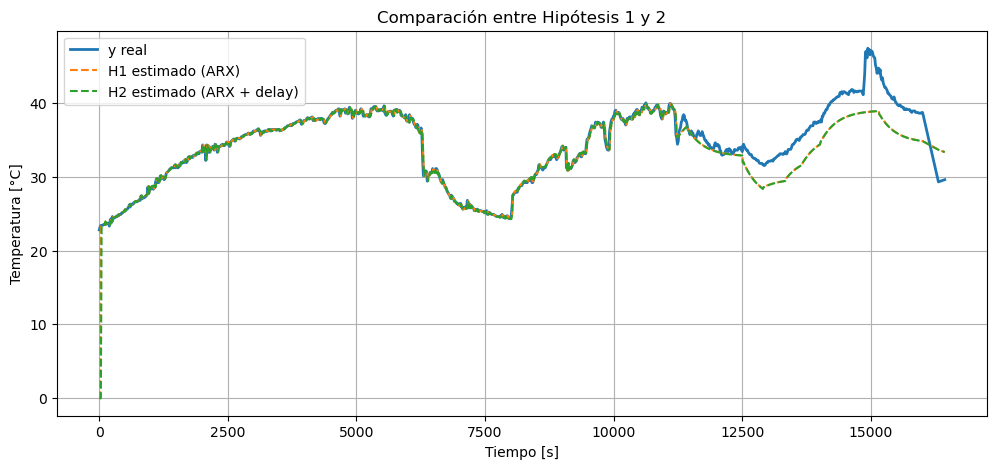

In [ ]:
#Inserte el código en este espacio.

y2_full = np.zeros_like(y)

# entrenamiento: one-step
y2_full[start_k:split] = y_pred_train

# validación: free-run
y2_full[split:] = y_sim

# Métricas ECM y R²

def ECM(a, b):
    return np.mean((a - b)**2)

def R2(a, b):
    return 1 - np.sum((a-b)**2) / np.sum((a - np.mean(a))**2)

# Hipótesis 1
ECM_H1 = ECM(y, y_e_full)
R2_H1  = R2(y, y_e_full)

# Hipótesis 2
ECM_H2 = ECM(y, y2_full)
R2_H2  = R2(y, y2_full)

# Tabla comparativa


print("           COMPARACIÓN FINAL")
print(f"Hipótesis 1 → ECM = {ECM_H1:.6f}   |   R² = {R2_H1:.5f}")
print(f"Hipótesis 2 → ECM = {ECM_H2:.6f}   |   R² = {R2_H2:.5f}")


#  Gráfica comparativa de H1 vs H2


plt.figure(figsize=(12,5))
plt.plot(t, y, label="y real", linewidth=2)
plt.plot(t, y_e_full, '--', label="H1 estimado (ARX)")
plt.plot(t, y2_full, '--', label="H2 estimado (ARX + delay)")

plt.title("Comparación entre Hipótesis 1 y 2")
plt.xlabel("Tiempo [s]")
plt.ylabel("Temperatura [°C]")
plt.grid(True)
plt.legend()
plt.show()


## Conclusiones

* Redacte aquí un conjunto de conclusiones relacionadas directamente con los resultados obtenidos...

. 1. La hipótesis 1 muestra mejor ajuste en modo One-Step Ahead

En la primera hipótesis, el modelo ARX logró un R² = 0.9787 y un ECM = 0.3375, lo que indica que la salida estimada sigue muy bien la señal real cuando se usa la predicción de un paso adelante. Esto se refleja en la gráfica donde ambas curvas prácticamente se superponen, mostrando un comportamiento suave y una buena captura de la dinámica dominante del sistema.

2. En modo Free-Run el modelo pierde precisión, indicando que el sistema es más complejo

La hipótesis 1 presenta un R² = 0.2480 y un ECM = 11.9118 en modo Free-Run, lo cual evidencia que el modelo no puede predecir adecuadamente la salida cuando no usa la referencia real. Esto se observa en la gráfica donde la señal estimada se desvía progresivamente de la señal medida. Esto sugiere que el sistema tiene dinámicas no lineales o ruido que un ARX sencillo no logra capturar completamente.

3. La hipótesis 2 mejora el desempeño general pero sigue sin superar a la hipótesis 1

El modelo de la hipótesis 2 logró un R² = 0.9444 y un ECM = 1.3862, lo cual es un buen resultado, pero inferior al de la hipótesis 1 en one-step-ahead. En las gráficas se nota que la estimación sigue el comportamiento general, pero con más diferencia en picos y transiciones. Aunque la estructura es diferente, la hipótesis 1 sigue siendo la que mejor representa la dinámica para predicción a corto plazo.

El proceso de identificación mediante modelos ARX permitió analizar y comparar diferentes estructuras de polinomios para representar la dinámica del sistema. Los resultados muestran que, aunque ambos modelos presentan un comportamiento aceptable, la Hipótesis 1 ofrece el mejor desempeño, especialmente en modo one-step-ahead, donde alcanza un R² cercano al 98%, indicando un ajuste muy preciso entre la salida real y la estimada. No obstante, el desempeño disminuye notablemente en el modo free-run, lo que evidencia que el sistema real posee dinámicas más complejas o perturbaciones que no son capturadas completamente por un modelo ARX básico. En conjunto, el ejercicio permitió comprender las limitaciones y ventajas de este tipo de modelos, así como la importancia de seleccionar adecuadamente los órdenes de los polinomios y validar el comportamiento tanto numérica como gráficamente para lograr una representación confiable del sistema.



